EDA(Exploratory Data Analysis) and Data Visualisation

In [2]:
#importing librabries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
project2 = pd.read_excel('Project1_cleaned_data.xlsx')
project2

,Unnamed: 0,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,1195,ORD201195,2024-06-20,C21126,Desk,1,107.04,392 Main St,Credit Card,Cancelled,TRK38009181,6,FREESHIP,Google,107.04
1196,1196,ORD201196,2024-03-04,C20095,Monitor,2,662.53,778 Main St,Online,Cancelled,TRK69207593,5,NO COUPON CODE,Facebook,1325.06
1197,1197,ORD201197,2023-07-13,C79674,Tablet,2,436.84,275 Main St,Online,Delivered,TRK88039356,2,FREESHIP,Instagram,873.68
1198,1198,ORD201198,2024-08-22,C64753,Chair,4,262.52,509 Main St,Debit Card,Cancelled,TRK71683331,4,WINTER15,Instagram,1050.08


In [4]:
project2 = project2.drop('Unnamed: 0', axis=1)
project2

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,ORD201195,2024-06-20,C21126,Desk,1,107.04,392 Main St,Credit Card,Cancelled,TRK38009181,6,FREESHIP,Google,107.04
1196,ORD201196,2024-03-04,C20095,Monitor,2,662.53,778 Main St,Online,Cancelled,TRK69207593,5,NO COUPON CODE,Facebook,1325.06
1197,ORD201197,2023-07-13,C79674,Tablet,2,436.84,275 Main St,Online,Delivered,TRK88039356,2,FREESHIP,Instagram,873.68
1198,ORD201198,2024-08-22,C64753,Chair,4,262.52,509 Main St,Debit Card,Cancelled,TRK71683331,4,WINTER15,Instagram,1050.08


In [5]:
#statistics
cols = ['Quantity', 'UnitPrice', 'TotalPrice']
for col in cols:
    if col in project2.columns:
        print(f"{col}:")
        print(f"Count: {project2[col].count()}")
        print(f"Mean: {project2[col].mean()}")
        print(f"Median: {project2[col].median()}\n")

Quantity:
Count: 1200
Mean: 2.9458333333333333
Median: 3.0

UnitPrice:
Count: 1200
Mean: 356.41275
Median: 364.21

TotalPrice:
Count: 1200
Mean: 1053.3382916666667
Median: 823.615



In [6]:
#Extracting year
project2['Year'] = project2['Date'].dt.year

In [7]:
#Making the year column to be an integer
project2['Year'] = pd.to_numeric(project2['Year'],errors='coerce').astype('Int64')

In [8]:
#Extracting month 
project2['Month'] = project2['Date'].dt.strftime('%b')
project2['Month']

0       Jan
1       Aug
2       Feb
3       Oct
4       May
       ... 
1195    Jun
1196    Mar
1197    Jul
1198    Aug
1199    Jun
Name: Month, Length: 1200, dtype: object

Business Questions

Text(0.5, 1.0, 'Monthly Revenue Trend')

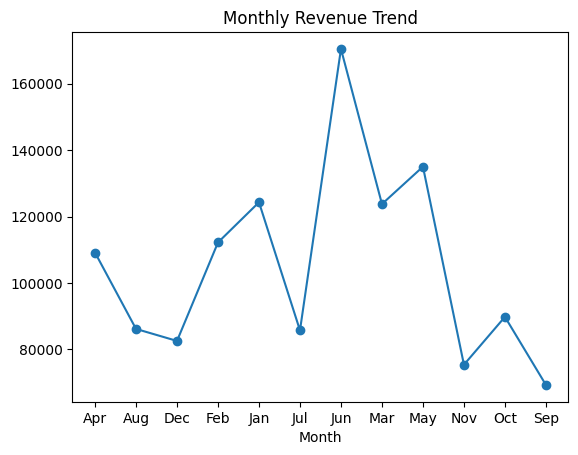

In [9]:
#1. monthly revneue and yearly revenue 
monthly_reve = project2.groupby('Month')['TotalPrice'].sum()
plt.plot(monthly_reve.index, monthly_reve.values, marker='o')
plt.xlabel('Month')
plt.title('Monthly Revenue Trend')

Text(0.5, 1.0, 'Yearly Revenue Trend')

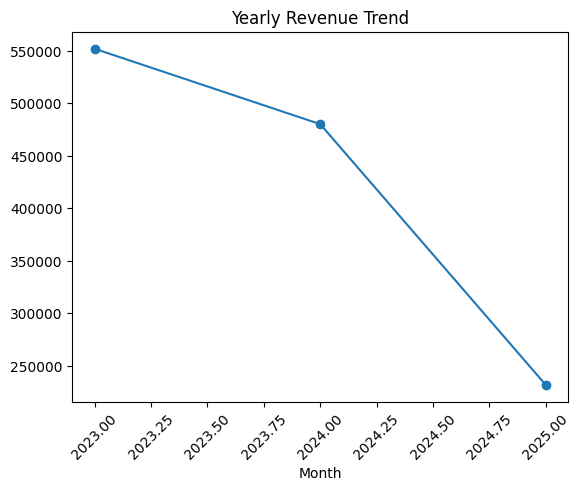

In [10]:
#Yearly Revenue
yearly_reve = project2.groupby('Year')['TotalPrice'].sum()
plt.plot(yearly_reve.index, yearly_reve.values, marker='o')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.title('Yearly Revenue Trend')

Text(0.5, 1.0, 'Revenue by Products')

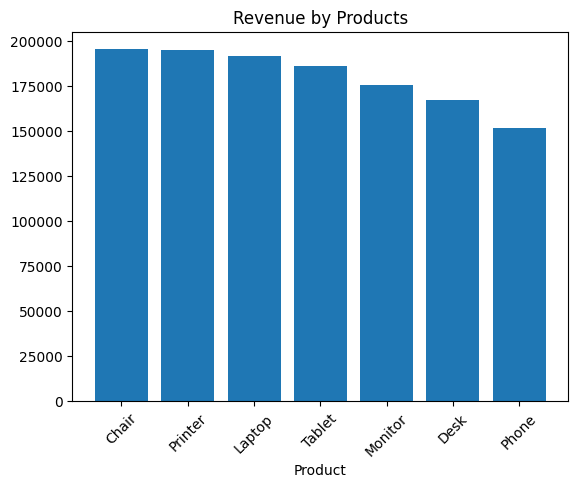

In [11]:
#2. Sales and Revenue Performance
# Which products and referral source drive the most total revenue
product = project2.groupby('Product')['TotalPrice'].sum()
products = product.sort_values(ascending=False)
plt.bar(products.index, products.values, label='Revenue')
plt.xlabel('Product')
plt.xticks(rotation=45)
plt.title('Revenue by Products')

Text(0.5, 1.0, 'Revenue by Referral Source')

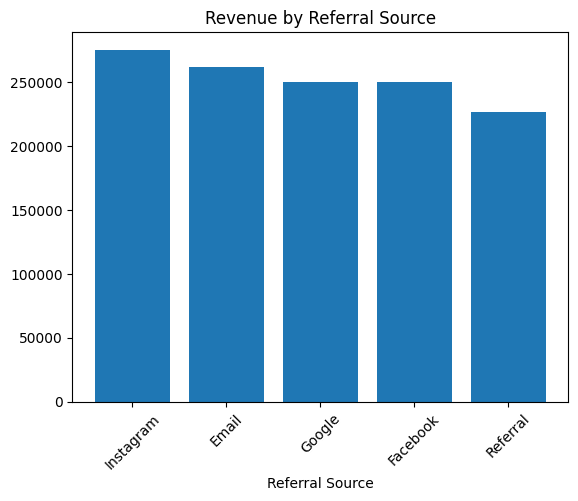

In [12]:
# Total revenue by Referral source
sale = project2.groupby('ReferralSource')['TotalPrice'].sum()
sales = sale.sort_values(ascending=False)
plt.bar(sales.index, sales.values, label='Revenue')
plt.xlabel('Referral Source')
plt.xticks(rotation=45)
plt.title('Revenue by Referral Source')

In [13]:
#Creating a new column called coupon status
coupons = ['SAVE10', 'FREESHIP', 'WINTER15']
project2['CouponStatus'] = np.where(project2['CouponCode'].isin(coupons), 'Coupon Used', 'Coupon not Used')

Text(0.5, 1.0, 'Revenue by Coupon Codes')

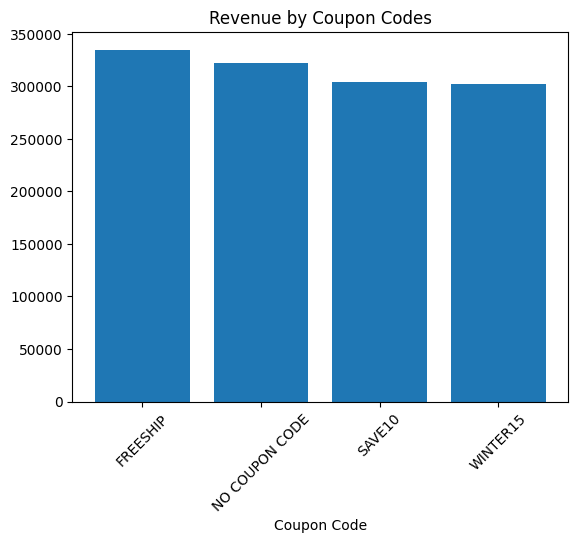

In [14]:
#3. Customer behavior and Retention
#Do customers who use coupon codes have higher revenue
customer = project2.groupby('CouponCode')['TotalPrice'].sum()
customers = customer.sort_values(ascending=False)
plt.bar(customers.index, customers.values, label='Revenue')
plt.xlabel('Coupon Code')
plt.xticks(rotation=45)
plt.title('Revenue by Coupon Codes')


Text(0.5, 1.0, 'Order Status Breakdown')

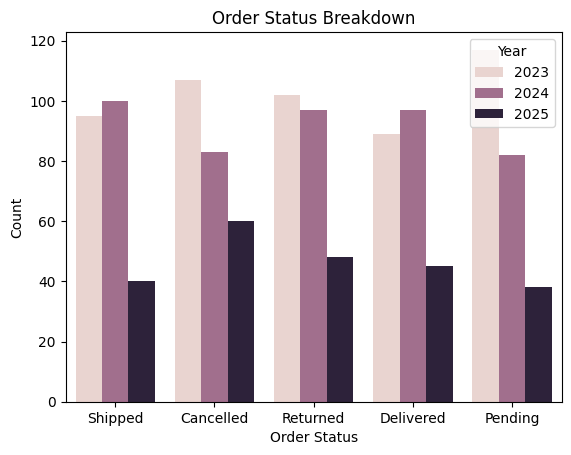

In [15]:
#3. Operations & Fulfillment
#What is our order status breakdown and year?
sns.countplot(x='OrderStatus', data=project2, hue='Year')
plt.xlabel('Order Status')
plt.ylabel('Count')
plt.title('Order Status Breakdown')

In [16]:
#Checking the value count of the order status 
project2['OrderStatus'].value_counts()

OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64

In [17]:
#Checking the total number of repeated customers that we have
#count how many orders each customer has
orders_per_customer = project2.groupby('CustomerID')['OrderID'].nunique()

#Filter customers who order more than once
repeat_customers = orders_per_customer[orders_per_customer > 1]

#The total count 
total_repeat_customers = len(repeat_customers)
print(f"Total Repeated Customers : {total_repeat_customers}")

Total Repeated Customers : 11


Text(0.5, 1.0, 'Total Number of items in Cart by Payment Method')

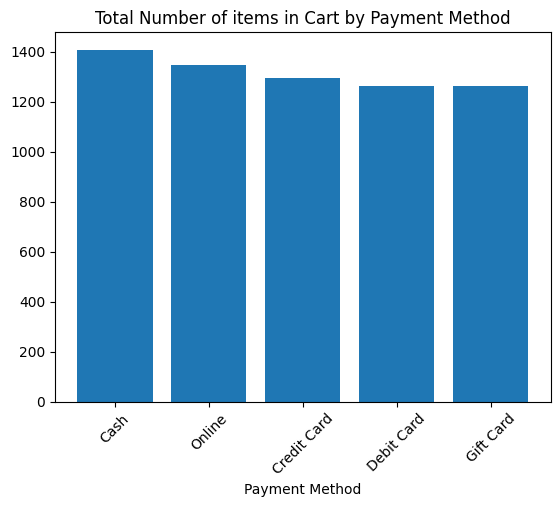

In [18]:
#4.Basket Analysis
#How does number of items in cart relate to payment
#items in cart vs payment
item = project2.groupby('PaymentMethod')['ItemsInCart'].sum()
items = item.sort_values(ascending=False)
plt.bar(items.index, items.values)
plt.xlabel('Payment Method')
plt.xticks(rotation=45)
plt.title('Total Number of items in Cart by Payment Method')
